# Earnings Prediction Engine V1

This notebook builds a free-data prototype for predicting whether a company will beat, meet, or miss consensus EPS expectations. It is designed as a quantitative research practice project, not as a production trading system.

Core research rules in this notebook:

- Use only information available before the earnings announcement when building features.
- Use time-based train/test splits, never random splits.
- Compare machine learning models against a simple baseline.
- Evaluate both classification performance and quant-style ranking behavior.

## 1. Imports and Configuration

In [28]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = '2018-01-01'
END_DATE = None
MEET_TOLERANCE = 0.01
MIN_OBSERVATIONS = 120

# A liquid starter universe. Keep this modest while learning because yfinance calls can be slow.
TICKERS = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'TSLA', 'AVGO', 'COST',
    'JPM', 'V', 'MA', 'UNH', 'HD', 'WMT', 'PG', 'JNJ', 'XOM', 'LLY',
    'BAC', 'KO', 'PEP', 'ADBE', 'CRM', 'NFLX', 'AMD', 'INTC', 'CSCO', 'ORCL',
    'MCD', 'DIS', 'NKE', 'T', 'VZ', 'PFE', 'MRK', 'CVX', 'ABBV', 'WFC',
    'GS', 'MS', 'C', 'BA', 'CAT', 'GE', 'IBM', 'QCOM', 'TXN', 'AMAT'
]

print(f'Project root: {ROOT}')
print(f'Universe size: {len(TICKERS)} tickers')

Project root: C:\Users\Asus\Documents\New project
Universe size: 50 tickers


## 2. Data Collection

`yfinance` data can be incomplete. The helper functions below fail softly so one bad ticker does not break the full research run.

In [16]:
def clean_earnings_dates(raw: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if raw is None or raw.empty:
        return pd.DataFrame()

    df = raw.reset_index().copy()
    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]

    date_col = next((c for c in df.columns if 'earnings' in c and 'date' in c), df.columns[0])
    estimate_col = next((c for c in df.columns if 'eps_estimate' in c or c == 'eps_estimate'), None)
    actual_col = next((c for c in df.columns if 'reported_eps' in c or c == 'reported_eps'), None)

    if estimate_col is None or actual_col is None:
        return pd.DataFrame()

    out = df[[date_col, estimate_col, actual_col]].rename(
        columns={date_col: 'earnings_date', estimate_col: 'estimated_eps', actual_col: 'actual_eps'}
    )
    out['ticker'] = ticker
    out['earnings_date'] = pd.to_datetime(out['earnings_date'], errors='coerce').dt.tz_localize(None)
    out['estimated_eps'] = pd.to_numeric(out['estimated_eps'], errors='coerce')
    out['actual_eps'] = pd.to_numeric(out['actual_eps'], errors='coerce')
    out = out.dropna(subset=['earnings_date', 'estimated_eps', 'actual_eps'])
    out = out[out['earnings_date'] >= pd.Timestamp(START_DATE)]
    return out.sort_values(['ticker', 'earnings_date']).reset_index(drop=True)


def fetch_earnings_for_ticker(ticker: str) -> pd.DataFrame:
    try:
        tk = yf.Ticker(ticker)
        raw = tk.get_earnings_dates(limit=80)
        return clean_earnings_dates(raw, ticker)
    except Exception as exc:
        print(f'Could not fetch earnings for {ticker}: {exc}')
        return pd.DataFrame()


earnings_frames = [fetch_earnings_for_ticker(ticker) for ticker in TICKERS]
earnings = pd.concat([f for f in earnings_frames if not f.empty], ignore_index=True) if earnings_frames else pd.DataFrame()
earnings = earnings.sort_values(['ticker', 'earnings_date']).reset_index(drop=True)

earnings['surprise'] = earnings['actual_eps'] - earnings['estimated_eps']
earnings['surprise_pct'] = earnings['surprise'] / earnings['estimated_eps'].abs().replace(0, np.nan)
earnings['target'] = np.select(
    [earnings['surprise'] > MEET_TOLERANCE, earnings['surprise'] < -MEET_TOLERANCE],
    ['beat', 'miss'],
    default='meet'
)

earnings.to_csv(RAW_DIR / 'earnings_raw_yfinance.csv', index=False)
print(earnings.shape)
earnings.head()

(1666, 7)


,earnings_date,estimated_eps,actual_eps,ticker,surprise,surprise_pct,target
0,2018-02-01 16:00:00,0.96,0.97,AAPL,0.01,0.010417,beat
1,2018-05-01 16:00:00,0.67,0.68,AAPL,0.01,0.014925,beat
2,2018-07-31 16:00:00,0.54,0.59,AAPL,0.05,0.092593,beat
3,2018-11-01 16:00:00,0.70,0.73,AAPL,0.03,0.042857,beat
4,2019-01-29 16:00:00,1.04,1.05,AAPL,0.01,0.009615,beat


In [17]:
def fetch_price_history(tickers: list[str]) -> pd.DataFrame:
    prices = yf.download(
        tickers=tickers + ['SPY'],
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        group_by='ticker',
        progress=False,
        threads=True,
    )

    rows = []
    for ticker in tickers + ['SPY']:
        try:
            part = prices[ticker].copy() if isinstance(prices.columns, pd.MultiIndex) else prices.copy()
            part = part.reset_index()
            part['ticker'] = ticker
            rows.append(part)
        except Exception:
            continue

    out = pd.concat(rows, ignore_index=True)
    out.columns = [str(c).lower().replace(' ', '_') for c in out.columns]
    out = out.rename(columns={'date': 'price_date'})
    out['price_date'] = pd.to_datetime(out['price_date']).dt.tz_localize(None)
    return out.sort_values(['ticker', 'price_date']).reset_index(drop=True)


prices = fetch_price_history(TICKERS)
prices.to_csv(RAW_DIR / 'prices_raw_yfinance.csv', index=False)
print(prices.shape)
prices.head()

(106539, 7)


,price_date,open,high,low,close,volume,ticker
0,2018-01-02,39.812832,40.313533,39.602254,40.304173,102223600,AAPL
1,2018-01-03,40.367350,40.839976,40.233987,40.297157,118071600,AAPL
2,2018-01-04,40.369681,40.587278,40.262056,40.484329,89738400,AAPL
3,2018-01-05,40.580258,41.031824,40.489009,40.945255,94640000,AAPL
4,2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200,AAPL


## 3. Optional Fundamental Features

`yfinance` quarterly financial statement history is shallow. These features are useful for learning, but they are not a Compustat replacement. To reduce leakage risk, fundamentals are attached only when the fiscal period ended at least 45 days before the earnings event.

In [18]:
def fetch_quarterly_fundamentals(ticker: str) -> pd.DataFrame:
    try:
        financials = yf.Ticker(ticker).quarterly_financials
        if financials is None or financials.empty:
            return pd.DataFrame()

        wanted = ['Total Revenue', 'Gross Profit', 'Net Income']
        available = [row for row in wanted if row in financials.index]
        if not available:
            return pd.DataFrame()

        out = financials.loc[available].T.reset_index().rename(columns={'index': 'fiscal_period_end'})
        out['ticker'] = ticker
        out['fiscal_period_end'] = pd.to_datetime(out['fiscal_period_end'], errors='coerce').dt.tz_localize(None)
        out = out.rename(columns={
            'Total Revenue': 'revenue',
            'Gross Profit': 'gross_profit',
            'Net Income': 'net_income',
        })
        for col in ['revenue', 'gross_profit', 'net_income']:
            if col not in out.columns:
                out[col] = np.nan
            out[col] = pd.to_numeric(out[col], errors='coerce')

        out = out.sort_values(['ticker', 'fiscal_period_end'])
        out['revenue_growth_qoq'] = out.groupby('ticker')['revenue'].pct_change()
        out['gross_margin'] = out['gross_profit'] / out['revenue'].replace(0, np.nan)
        out['gross_margin_change_qoq'] = out.groupby('ticker')['gross_margin'].diff()
        out['net_income_growth_qoq'] = out.groupby('ticker')['net_income'].pct_change()
        return out[['ticker', 'fiscal_period_end', 'revenue_growth_qoq', 'gross_margin_change_qoq', 'net_income_growth_qoq']]
    except Exception as exc:
        print(f'Could not fetch fundamentals for {ticker}: {exc}')
        return pd.DataFrame()


fundamental_frames = [fetch_quarterly_fundamentals(ticker) for ticker in TICKERS]
fundamentals = pd.concat([f for f in fundamental_frames if not f.empty], ignore_index=True) if fundamental_frames else pd.DataFrame()
fundamentals = fundamentals.replace([np.inf, -np.inf], np.nan)
fundamentals.to_csv(RAW_DIR / 'fundamentals_raw_yfinance.csv', index=False)
print(fundamentals.shape)
fundamentals.head()

(292, 5)


,ticker,fiscal_period_end,revenue_growth_qoq,gross_margin_change_qoq,net_income_growth_qoq
0,AAPL,2024-12-31,NaN,NaN,NaN
1,AAPL,2025-03-31,-0.232832,0.001681,-0.317919
2,AAPL,2025-06-30,-0.013874,-0.005599,-0.054318
3,AAPL,2025-09-30,0.089647,0.006869,0.172058
4,AAPL,2025-12-31,0.402963,0.009811,0.532695


## 4. Technical and Historical Earnings Features

The technical features use prices strictly before the earnings date. This avoids using the market reaction after the announcement.

In [19]:
def add_return_columns(price_df: pd.DataFrame) -> pd.DataFrame:
    out = price_df.copy()
    out['daily_return'] = out.groupby('ticker')['close'].pct_change()
    out['ret_5d'] = out.groupby('ticker')['close'].pct_change(5)
    out['ret_20d'] = out.groupby('ticker')['close'].pct_change(20)
    out['ret_60d'] = out.groupby('ticker')['close'].pct_change(60)
    out['vol_20d'] = out.groupby('ticker')['daily_return'].transform(lambda s: s.rolling(20).std())
    out['volume_ratio_20d'] = out['volume'] / out.groupby('ticker')['volume'].transform(lambda s: s.rolling(20).mean())
    return out


prices_with_features = add_return_columns(prices)
spy = prices_with_features[prices_with_features['ticker'] == 'SPY'][['price_date', 'ret_20d', 'ret_60d']].rename(
    columns={'ret_20d': 'spy_ret_20d', 'ret_60d': 'spy_ret_60d'}
)

stock_prices = prices_with_features[prices_with_features['ticker'] != 'SPY'].copy()
stock_prices = stock_prices.merge(spy, on='price_date', how='left')
stock_prices['rel_ret_20d'] = stock_prices['ret_20d'] - stock_prices['spy_ret_20d']
stock_prices['rel_ret_60d'] = stock_prices['ret_60d'] - stock_prices['spy_ret_60d']

technical_cols = [
    'ticker', 'price_date', 'ret_5d', 'ret_20d', 'ret_60d', 'vol_20d',
    'volume_ratio_20d', 'rel_ret_20d', 'rel_ret_60d'
]
technical = stock_prices[technical_cols].dropna(subset=['price_date'])
technical.head()

,ticker,price_date,ret_5d,ret_20d,ret_60d,vol_20d,volume_ratio_20d,rel_ret_20d,rel_ret_60d
0,AAPL,2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
def attach_latest_pre_event_features(events: pd.DataFrame, features: pd.DataFrame) -> pd.DataFrame:
    events_sorted = events.sort_values(['ticker', 'earnings_date']).copy()
    features_sorted = features.sort_values(['ticker', 'price_date']).copy()

    merged_parts = []
    for ticker, event_part in events_sorted.groupby('ticker'):
        feature_part = features_sorted[features_sorted['ticker'] == ticker]
        if feature_part.empty:
            continue

        # The right table is shifted by one trading day because features must be known before the event day.
        feature_part = feature_part.copy()
        feature_part['feature_available_date'] = feature_part['price_date']
        merged = pd.merge_asof(
            event_part.sort_values('earnings_date'),
            feature_part.sort_values('feature_available_date'),
            left_on='earnings_date',
            right_on='feature_available_date',
            by='ticker',
            direction='backward',
            allow_exact_matches=False,
        )
        merged_parts.append(merged)

    return pd.concat(merged_parts, ignore_index=True) if merged_parts else pd.DataFrame()


dataset = attach_latest_pre_event_features(earnings, technical)
dataset = dataset.sort_values(['ticker', 'earnings_date']).reset_index(drop=True)

dataset['prior_surprise'] = dataset.groupby('ticker')['surprise'].shift(1)
dataset['prior_surprise_pct'] = dataset.groupby('ticker')['surprise_pct'].shift(1)
dataset['prior_beat'] = (dataset.groupby('ticker')['target'].shift(1) == 'beat').astype(float)
dataset['beat_rate_last_4'] = dataset.groupby('ticker')['prior_beat'].transform(lambda s: s.rolling(4, min_periods=1).mean())
dataset['avg_surprise_last_4'] = dataset.groupby('ticker')['prior_surprise'].transform(lambda s: s.rolling(4, min_periods=1).mean())
dataset['estimated_eps_change_qoq'] = dataset.groupby('ticker')['estimated_eps'].pct_change().replace([np.inf, -np.inf], np.nan)

if not fundamentals.empty:
    fundamental_parts = []
    for ticker, event_part in dataset.groupby('ticker'):
        fundamental_part = fundamentals[fundamentals['ticker'] == ticker].copy()
        if fundamental_part.empty:
            continue
        event_part = event_part.copy()
        event_part['fundamental_cutoff_date'] = event_part['earnings_date'] - pd.Timedelta(days=45)
        merged = pd.merge_asof(
            event_part.sort_values('fundamental_cutoff_date'),
            fundamental_part.sort_values('fiscal_period_end'),
            left_on='fundamental_cutoff_date',
            right_on='fiscal_period_end',
            by='ticker',
            direction='backward',
        )
        fundamental_parts.append(merged)
    if fundamental_parts:
        dataset = pd.concat(fundamental_parts, ignore_index=True)

dataset = dataset.dropna(subset=['target', 'ret_20d', 'vol_20d']).reset_index(drop=True)
dataset.to_csv(PROCESSED_DIR / 'earnings_features_v1.csv', index=False)

print(dataset.shape)
dataset[['ticker', 'earnings_date', 'estimated_eps', 'actual_eps', 'surprise', 'target']].head()

(1646, 27)


,ticker,earnings_date,estimated_eps,actual_eps,surprise,target
0,AAPL,2018-02-01 16:00:00,0.96,0.97,0.01,beat
1,AAPL,2018-05-01 16:00:00,0.67,0.68,0.01,beat
2,AAPL,2018-07-31 16:00:00,0.54,0.59,0.05,beat
3,AAPL,2018-11-01 16:00:00,0.70,0.73,0.03,beat
4,AAPL,2019-01-29 16:00:00,1.04,1.05,0.01,beat


## 5. Dataset Diagnostics

Observations: 1646
Tickers: 50
Date range: 2018-01-31 06:00:00 to 2026-04-24 07:00:00


target
beat    0.802552
miss    0.140340
meet    0.057108
Name: class_share, dtype: float64

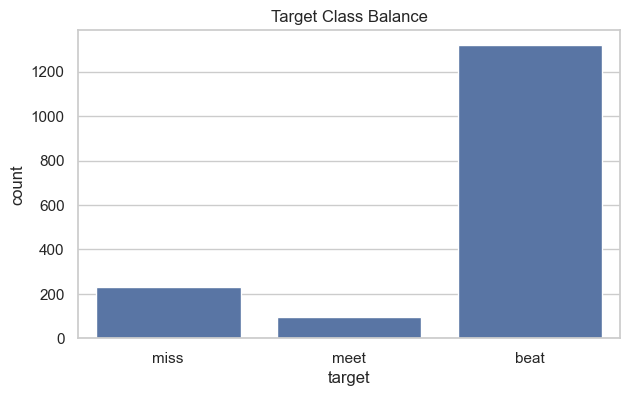

In [21]:
print('Observations:', len(dataset))
print('Tickers:', dataset['ticker'].nunique())
print('Date range:', dataset['earnings_date'].min(), 'to', dataset['earnings_date'].max())
display(dataset['target'].value_counts(normalize=True).rename('class_share'))

plt.figure(figsize=(7, 4))
sns.countplot(data=dataset, x='target', order=['miss', 'meet', 'beat'])
plt.title('Target Class Balance')
plt.show()

## 6. Time-Based Train/Test Split

In [22]:
if len(dataset) < MIN_OBSERVATIONS:
    print(f'Warning: only {len(dataset)} observations. Add more tickers or check yfinance coverage.')

dataset = dataset.sort_values('earnings_date').reset_index(drop=True)
train_cutoff = dataset['earnings_date'].quantile(0.70)
valid_cutoff = dataset['earnings_date'].quantile(0.85)

train = dataset[dataset['earnings_date'] <= train_cutoff].copy()
valid = dataset[(dataset['earnings_date'] > train_cutoff) & (dataset['earnings_date'] <= valid_cutoff)].copy()
test = dataset[dataset['earnings_date'] > valid_cutoff].copy()

print('Train:', train['earnings_date'].min(), train['earnings_date'].max(), train.shape)
print('Valid:', valid['earnings_date'].min(), valid['earnings_date'].max(), valid.shape)
print('Test:', test['earnings_date'].min(), test['earnings_date'].max(), test.shape)

Train: 2018-01-31 06:00:00 2023-10-25 16:00:00 (1153, 27)
Valid: 2023-10-26 06:00:00 2025-01-30 06:00:00 (246, 27)
Test: 2025-01-30 08:00:00 2026-04-24 07:00:00 (247, 27)


## 7. Model Training

In [23]:
feature_cols = [
    'estimated_eps', 'estimated_eps_change_qoq',
    'prior_surprise', 'prior_surprise_pct', 'beat_rate_last_4', 'avg_surprise_last_4',
    'ret_5d', 'ret_20d', 'ret_60d', 'vol_20d', 'volume_ratio_20d', 'rel_ret_20d', 'rel_ret_60d'
]
fundamental_feature_cols = ['revenue_growth_qoq', 'gross_margin_change_qoq', 'net_income_growth_qoq']
feature_cols = feature_cols + [c for c in fundamental_feature_cols if c in dataset.columns]

X_train, y_train = train[feature_cols], train['target']
X_valid, y_valid = valid[feature_cols], valid['target']
X_test, y_test = test[feature_cols], test['target']

numeric_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, feature_cols)
])

models = {
    'dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
    'logistic_regression': Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='auto')),
    ]),
    'random_forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=8,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    'hist_gradient_boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(max_iter=200, learning_rate=0.04, max_leaf_nodes=15, random_state=42)),
    ]),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    for split_name, X, y in [('valid', X_valid, y_valid), ('test', X_test, y_test)]:
        pred = model.predict(X)
        results.append({
            'model': name,
            'split': split_name,
            'accuracy': accuracy_score(y, pred),
            'macro_f1': f1_score(y, pred, average='macro'),
        })

results_df = pd.DataFrame(results).sort_values(['split', 'macro_f1'], ascending=[True, False])
results_df

,model,split,accuracy,macro_f1
3,logistic_regression,test,0.676113,0.405049
5,random_forest,test,0.688259,0.352639
7,hist_gradient_boosting,test,0.805668,0.327470
1,dummy_most_frequent,test,0.834008,0.303164
4,random_forest,valid,0.715447,0.455782
2,logistic_regression,valid,0.613821,0.400806
6,hist_gradient_boosting,valid,0.788618,0.311098
0,dummy_most_frequent,valid,0.808943,0.298127


## 8. Evaluation

Best validation model: random_forest
              precision    recall  f1-score   support

        miss       0.20      0.29      0.24        34
        meet       0.00      0.00      0.00         7
        beat       0.87      0.78      0.82       206

    accuracy                           0.69       247
   macro avg       0.36      0.36      0.35       247
weighted avg       0.76      0.69      0.72       247



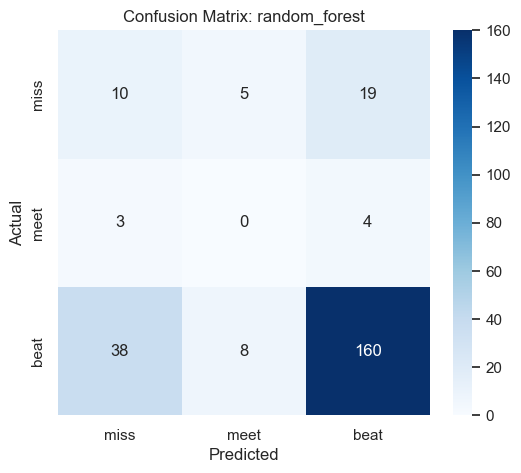

In [24]:
ml_valid_results = results_df[(results_df['split'] == 'valid') & (results_df['model'] != 'dummy_most_frequent')]
best_name = ml_valid_results.sort_values('macro_f1', ascending=False).iloc[0]['model'] if not ml_valid_results.empty else results_df[results_df['split'] == 'valid'].sort_values('macro_f1', ascending=False).iloc[0]['model']
best_model = fitted_models[best_name]
test_pred = best_model.predict(X_test)

print('Best validation model:', best_name)
print(classification_report(y_test, test_pred, labels=['miss', 'meet', 'beat']))

cm = confusion_matrix(y_test, test_pred, labels=['miss', 'meet', 'beat'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['miss', 'meet', 'beat'], yticklabels=['miss', 'meet', 'beat'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {best_name}')
plt.show()

,beat_score_quintile,observations,beat_rate,avg_surprise,avg_surprise_pct
0,1,50,0.660000,0.204600,7.855439
1,2,49,0.775510,0.126327,0.056710
2,3,49,0.795918,0.024286,0.033913
3,4,49,0.979592,0.249388,0.089970
4,5,50,0.960000,0.339000,0.115485


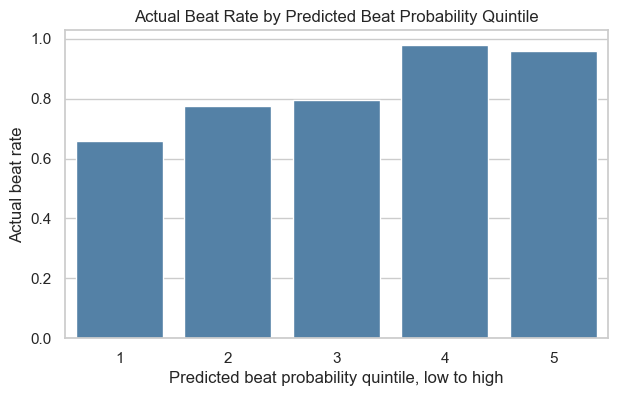

In [25]:
def prediction_frame(model, X: pd.DataFrame, base: pd.DataFrame) -> pd.DataFrame:
    out = base[['ticker', 'earnings_date', 'target', 'surprise', 'surprise_pct']].copy()
    if hasattr(model, 'predict_proba'):
        proba = pd.DataFrame(model.predict_proba(X), columns=[f'proba_{c}' for c in model.classes_], index=X.index)
        out = pd.concat([out.reset_index(drop=True), proba.reset_index(drop=True)], axis=1)
    else:
        out['proba_beat'] = np.nan
    out['predicted_label'] = model.predict(X)
    return out


preds = prediction_frame(best_model, X_test, test)
if 'proba_beat' in preds.columns and preds['proba_beat'].notna().sum() >= 10:
    preds['beat_score_quintile'] = pd.qcut(preds['proba_beat'].rank(method='first'), 5, labels=False) + 1
    quintile_summary = preds.groupby('beat_score_quintile').agg(
        observations=('target', 'size'),
        beat_rate=('target', lambda s: (s == 'beat').mean()),
        avg_surprise=('surprise', 'mean'),
        avg_surprise_pct=('surprise_pct', 'mean'),
    ).reset_index()
    display(quintile_summary)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=quintile_summary, x='beat_score_quintile', y='beat_rate', color='steelblue')
    plt.title('Actual Beat Rate by Predicted Beat Probability Quintile')
    plt.xlabel('Predicted beat probability quintile, low to high')
    plt.ylabel('Actual beat rate')
    plt.show()
else:
    print('Selected model does not provide enough probability estimates for quintile analysis.')

In [26]:
if 'proba_beat' in preds.columns and preds['proba_beat'].notna().sum() >= 10:
    quarterly = preds.dropna(subset=['proba_beat']).copy()
    quarterly['quarter'] = quarterly['earnings_date'].dt.to_period('Q').astype(str)
    quarterly_ic = quarterly.groupby('quarter').apply(
        lambda g: g['proba_beat'].corr((g['target'] == 'beat').astype(float), method='spearman') if len(g) >= 5 else np.nan
    ).rename('spearman_ic').reset_index()
    display(quarterly_ic)
    print('Average quarterly IC:', quarterly_ic['spearman_ic'].mean())

,quarter,spearman_ic
0,2025Q1,0.173301
1,2025Q2,0.382626
2,2025Q3,0.357476
3,2025Q4,0.359138
4,2026Q1,0.343015
5,2026Q2,0.068147


Average quarterly IC: 0.2806171345654193


## 9. Research Notes

Use this section after running the notebook:

- Did the ML models beat the dummy baseline on the test set?
- Did the top predicted beat quintile actually beat more often than the bottom quintile?
- Which classes were hardest to predict?
- Was the dataset large enough, or did free data coverage limit the experiment?
- Which V2 data source would improve the project most: I/B/E/S analyst revisions, Compustat fundamentals, or CRSP returns?